In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Question 1:
 
A retail store wants to identify customers who make frequent purchases. Given the dataset below, write a code to


In [2]:
data = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}


In [7]:
data1=list(data)

In [11]:
data1=pd.DataFrame(data)

1.	Group customers by their IDs.

In [21]:
group_customers=data1.groupby('Customer_ID')

2.	Calculate the total number of purchases per customer.

In [48]:
group_customers.sum()


,Purchase_Amount
Customer_ID,
101,520
102,600
103,480
104,300
105,400


3.	Identify the top 3 frequent customers.

In [50]:
customer_summary = data1.groupby('Customer_ID')['Purchase_Amount'].sum().reset_index()
# Now you have only 2 columns: Customer_ID and Purchase_Amount
sort = customer_summary.head(3)
sort = sort.sort_values('Purchase_Amount', ascending=False)
sort

,Customer_ID,Purchase_Amount
1,102,600
0,101,520
2,103,480


Question 2:
    
A company tracks the daily sales of a product over a month. You are tasked with identifying any 
abnormal sales data using the IQR (Interquartile Range) method.


In [87]:
data_sales = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}



In [88]:
data_sales=pd.DataFrame(data_sales)

1. Calculate the Q1 (25th percentile) and Q3 (75th percentile).

In [89]:
data_sales.describe()

,Day,Sales
count,30.000000,30.000000
mean,15.500000,58.466667
std,8.803408,39.401324
min,1.000000,22.000000
25%,8.250000,31.500000
50%,15.500000,43.000000
75%,22.750000,83.750000
max,30.000000,200.000000


In [90]:
q1=np.percentile(data_sales['Sales'],25)
q3=np.percentile(data_sales['Sales'],75)

2. Determine the IQR.

In [91]:
iqr=q3-q1
iqr

np.float64(52.25)

3. Identify the Lower Bound and Upper Bound.

In [92]:
lesser_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
print('Lesser Bound :',lesser_bound)
print('Upper Bound :',upper_bound)

Lesser Bound : -46.875
Upper Bound : 162.125


4. Detect and display the outliers.

In [93]:
outliers=data_sales[(data_sales['Sales']<lesser_bound) | (data_sales['Sales']>upper_bound)]

5. Replace the Outliers with the Median Value.

In [94]:
median=data_sales['Sales'].median()
data_sales['Sales']=np.where((data_sales['Sales']<lesser_bound)|(data_sales['Sales']>upper_bound),
                             median,data_sales['Sales'])

In [95]:
data_sales

,Day,Sales
0,1,25.0
1,2,30.0
2,3,28.0
3,4,45.0
4,5,55.0
5,6,60.0
6,7,22.0
7,8,80.0
8,9,95.0
9,10,120.0


Question 3:
 
A pharmaceutical company is testing the effectiveness of a new drug to reduce blood pressure. Two groups of patients were selected:

Group 1 (Treatment): Received the drug

Group 2 (Control): Received a placebo

The company wants to check if there is a significant difference in the blood pressure levels between the two groups using an Independent T-Test.


In [1]:
patients_data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}


In [4]:
patients_data=pd.DataFrame(patients_data)
patients_data

,Group,Blood_Pressure
0,Treatment,120
1,Treatment,115
2,Treatment,118
3,Treatment,123
4,Treatment,122
5,Treatment,119
6,Treatment,124
7,Treatment,117
8,Treatment,116
9,Treatment,121



1.	Perform an Independent T-Test.
2.	State the null and alternative hypotheses.
3.	Calculate the p-value.
4.	Conclude whether the drug has a significant effect.



In [11]:
from scipy.stats import ttest_ind
patients_data=patients_data.dropna()
treatment=patients_data[patients_data['Group']=='Treatment']['Blood_Pressure']
control=patients_data[patients_data['Group']=='Control']['Blood_Pressure']
t_statistic,p_value=ttest_ind(treatment,control)
print('T-Statistic :',t_statistic)
print('P-Value : ',p_value)


T-Statistic : -11.870553692962726
P-Value :  6.008066605173374e-10


Question 4:
GlobalMart is a large retailer conducting advertisement campaigns in different regions. The company spends money on two types of advertisements: TV Ads and Social Media Ads
They want to analyze how these ads influence their sales.
Your task is to calculate the Covariance and Correlation to determine which type of ad has a stronger impact on sales.


1.	Calculate the Covariance between ad budgets and sales to measure the direction of the relationship

In [13]:
import pandas as pd

# Create a DataFrame
globalmart_data = {'Region': ['North', 'South', 'East','West','Central'],
        'TV_Ad_Budget': [200, 300, 400, 500, 600],
        'Social_Media_Budget': [150, 250, 300, 450, 500],
                  'Sales':[20, 35, 50, 60, 80]}

df= pd.DataFrame(globalmart_data)

# Save to CSV
df.to_csv('output.csv', index=False)  # index=False removes row numbers

In [16]:
global_mart_dataset=pd.read_csv('output.csv')

In [17]:
global_mart_dataset

,Region,TV_Ad_Budget,Social_Media_Budget,Sales
0,North,200,150,20
1,South,300,250,35
2,East,400,300,50
3,West,500,450,60
4,Central,600,500,80


1.	Calculate the Covariance between ad budgets and sales to measure the direction of the relationship

In [23]:
cov=global_mart_dataset['TV_Ad_Budget'].cov(global_mart_dataset['Sales'])
print('Covariance (TV vs Sales) : ',cov)

Covariance (TV vs Sales) :  3625.0


In [25]:
cov1=global_mart_dataset['Social_Media_Budget'].cov(global_mart_dataset['Sales'])
print('Covariance (Social Media vs Sales) : ',cov1)

Covariance (Social Media vs Sales) :  3225.0


2.	Calculate the Correlation to measure the strength of the relationship.

In [26]:
cor=global_mart_dataset['TV_Ad_Budget'].corr(global_mart_dataset['Sales'])
print('Correlation (TV vs Sales) : ',cor)

Correlation (TV vs Sales) :  0.9958640886279954


In [27]:
cor1=global_mart_dataset['Social_Media_Budget'].corr(global_mart_dataset['Sales'])
print('Correlation (Social Media vs Sales) : ',cor1)

Correlation (Social Media vs Sales) :  0.9724846021568381


3.	Determine which type of ad is more effective for increasing sales.

Question 5:
A company tracks the delivery time (in minutes) for its online orders. You are given the delivery times for 50 orders


In [1]:
Del_dataset=[25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 
             50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200, 20, 
             25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]

In [14]:
#After changing the list into np array using numpy we were able to use the statacially functions 
Del_dataset=np.array(Del_dataset)

In [15]:
Mean=Del_dataset.mean()

In [16]:
std=Del_dataset.std()

In [17]:
print('Mean Delivery Time : ',Mean)
print('Standard Deviation of Devlivery Time : ',std)

Mean Delivery Time :  65.0625
Standard Deviation of Devlivery Time :  41.718504212759115


In [34]:
#get_pdf_probability(Del_dataset,25,160)

In [48]:
def get_pdf_probability(dataset, startrange, endrange):
    from scipy.stats import norm

    # Generate x values for the smooth PDF curve
    x = np.linspace(min(dataset) - 10, max(dataset) + 10, 1000)
    pdf_values = norm.pdf(x, mean, std)

    # Plot only the PDF curve (no histogram)
    plt.figure()
    plt.plot(pdf_values, color='red', label='Normal Distribution (PDF)')
    plt.xlabel('Delivery Time (minutes)')
    plt.ylabel('Density')
    plt.title('Probability Density Function (PDF)')
    plt.legend()
    plt.show()

    # Calculate probability between startrange and endrange
    dist = norm(Mean, std)
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]
    prob = sum(probabilities)

    return prob

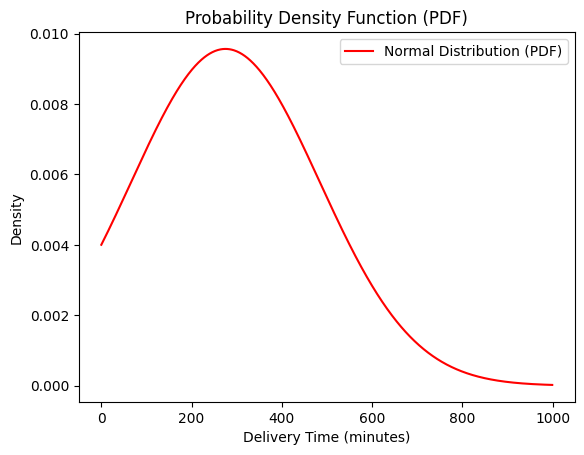

np.float64(0.8227576139044589)

In [49]:
get_pdf_probability(Del_dataset,25,160)